In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
suppressMessages(library(tidyr))
suppressMessages(library(foreach))
suppressMessages(library(doParallel))
suppressMessages(library(tidygraph))
suppressMessages(library(anndata))
suppressMessages(library(randomForest))
suppressMessages(library(pheatmap))
suppressMessages(library(dbscan))
suppressMessages(library(scDblFinder))
suppressMessages(library(cowplot))

# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


In [2]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_SCTseurat_harmony_rf_clean.rds')

In [3]:
DA= subset(seurat, Class == "DA")
DA

An object of class Seurat 
39743 features across 3676 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

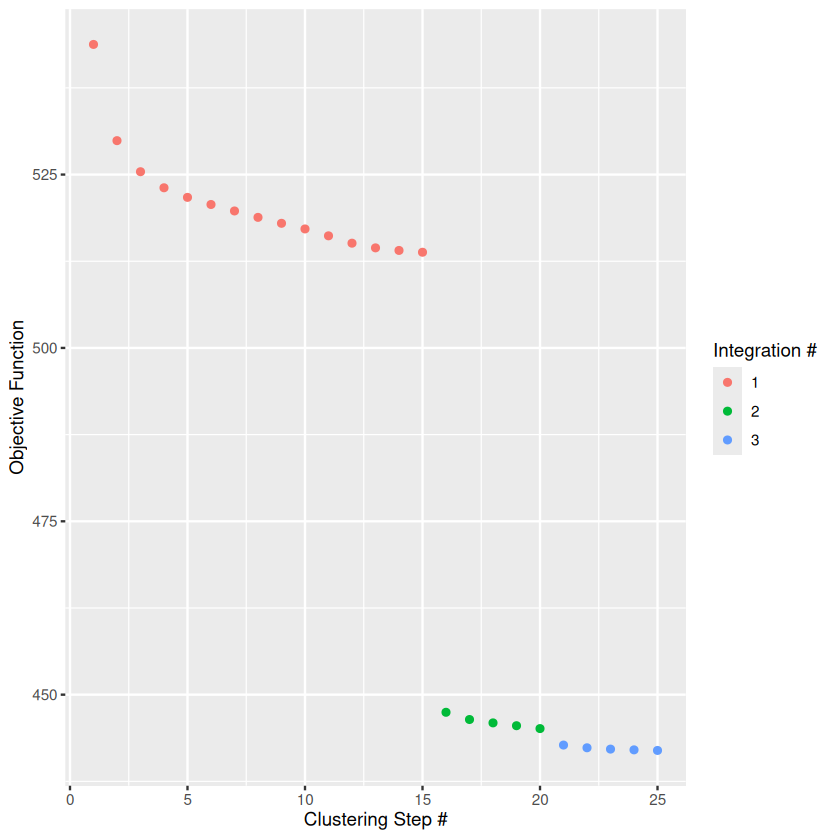

In [4]:
class_resolution = 0.3

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

sub = DA

assay = sub@assays$RNA$counts
meta = sub@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

sub = CreateSeuratObject(counts = new_assay)
sub = AddMetaData(sub, meta)

sub = NormalizeData(sub, normalization.method = "LogNormalize", scale.factor = 10000)
sub = FindVariableFeatures(sub, selection.method = "vst", nfeatures = 3000)
sub = ScaleData(sub, features = rownames(sub))

sub = sub %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

sub = RunHarmony(
    sub, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

sub = sub %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

In [125]:
sub_test = sub
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df2 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)

# 按照 index (细胞名/行名) 顺序添加
mouse_anno = c(df1$subclass_name, df2$subclass_name)
names(mouse_anno) = c(rownames(df1), rownames(df2))
# 只添加有 index 匹配的，用对象的 cell 名做索引
matched_anno = mouse_anno[colnames(sub_test)]
sub_test$Mouse_anno = matched_anno

In [106]:
stale_devices <- dev.list()
if (!is.null(stale_devices)) {
    stale_pdf_devices <- unname(stale_devices[names(stale_devices) == "pdf"])
    for (device_id in sort(stale_pdf_devices, decreasing = TRUE)) {
        dev.off(which = device_id)
    }
}

sub2 <- subset(sub_test, !(seurat_clusters %in% 8))
sub2$cluster <- paste0("DA_", sub2$seurat_clusters)
sub2$Mouse_anno <- as.character(sub2$Mouse_anno)
sub2$Mouse_anno[is.na(sub2$Mouse_anno)] <- "Unassigned"

anno_cluster_mat <- table(sub2$Mouse_anno, sub2$cluster)
valid_clusters <- apply(anno_cluster_mat, 2, function(x) sum(x) > 0 && sd(x) > 0)
anno_cluster_mat <- anno_cluster_mat[, valid_clusters, drop = FALSE]

if (nrow(anno_cluster_mat) < 2 || ncol(anno_cluster_mat) < 1) {
    stop("Heatmap requires at least two mouse annotations and one variable DA cluster.")
}

output_pdf <- "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_mapping_mouse_whole_brain.pdf"
dir.create(dirname(output_pdf), recursive = TRUE, showWarnings = FALSE)

pheatmap(
    anno_cluster_mat,
    scale = "column",
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    color = colorRampPalette(c("blue", "white", "red"))(100),
    border_color = NA,
    fontsize_row = 10,
    fontsize_col = 10,
    main = "Mapping to mouse whole-brain dataset",
    filename = output_pdf,
    width = 5,
    height = 6
)

In [127]:
table(sub_test$Mouse_anno, sub_test$seurat_clusters)

                                  
                                     0   1   2   3   4   5   6   7   8
  012 MEA Slc17a7 Glut               0   0   0   0   0   0   0   1   0
  030 L6 CT CTX Glut                 0   0   0   0   0   0   0   1   0
  043 OB-mi Frmd7 Gaba               0   0   0   0   0   0   0   0   1
  044 OB Dopa-Gaba                   0   0   0   0   0   0   0   1   0
  045 OB-STR-CTX Inh IMN             0   0   0   0   1   0   0   1   0
  046 Vip Gaba                       0   0   0   0   0   0   0   1   0
  057 NDB-SI-MA-STRv Lhx8 Gaba       0   0   0   0   1   0   0   1   0
  076 MEA-BST Lhx6 Nfib Gaba         0   0   0   0   1   0   0   0   0
  080 CEA-AAA-BST Six3 Sp9 Gaba      1   0   0   0   0   0   0   0   0
  086 MPO-ADP Lhx8 Gaba              0   0   0   0   0   0   0   1   0
  088 BST Tac2 Gaba                  0   0   0   0   1   0   0   0   0
  090 BST-MPN Six3 Nrgn Gaba         0   0   0   1   0   1   0   0   0
  091 ARH-PVi Six6 Dopa-Gaba         0   0

In [68]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_UMAP.pdf', width = 6, height = 5)

options(repr.plot.width=6, repr.plot.height=5)
Idents(sub2) <- 'cluster'
DimPlot(sub2, reduction="umap", label=T,raster=FALSE)+coord_fixed()

dev.off()

agg_record_905932227 
                   2

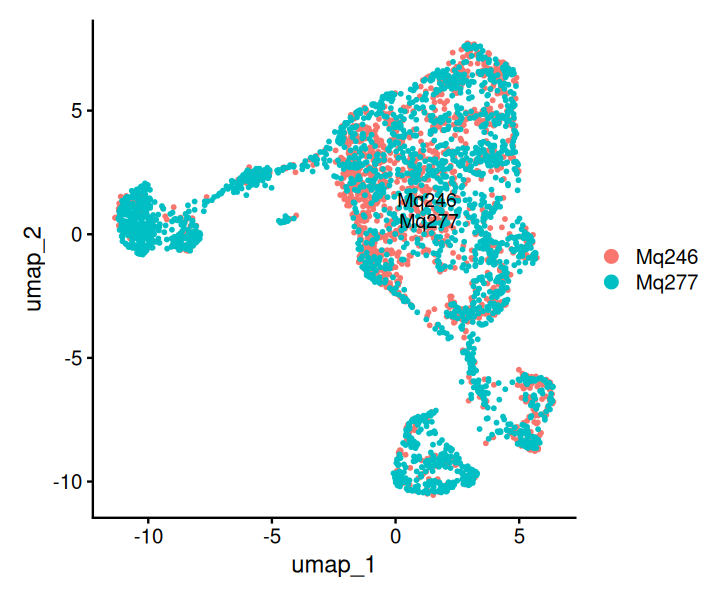

In [ ]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_UMAP.pdf', width = 6, height = 5)

options(repr.plot.width=6, repr.plot.height=5)
Idents(sub2) <- 'Animal'
DimPlot(sub2, reduction="umap", label=T,raster=FALSE)+coord_fixed()

dev.off()




In [52]:
sub2$cluster = paste0('DA_',sub2$seurat_clusters)
sub2$cluster %>% unique()

[1] "DA_3" "DA_7" "DA_0" "DA_2" "DA_5" "DA_4" "DA_6" "DA_1"

In [ ]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- sub2@meta.data %>%
    as.data.frame() %>%
    dplyr::count(cluster, Animal) %>%
    dplyr::group_by(cluster) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()
    


agg_record_312928385 
                   2

In [104]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_Animal_proportion.pdf',
    width = 4, height = 5)

options(repr.plot.width = 4, repr.plot.height = 5)

ggplot(cluster_animal_df, aes(x = proportion, y = factor(cluster), fill = Animal)) +
    geom_col(width = 0.8) +
    scale_x_continuous(labels = scales::percent_format()) +
    labs(x = "Animal proportion", y = "Cluster", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

dev.off()

agg_record_651436069 
                   2

In [ ]:
sub2 = subset(sub_test, !(seurat_clusters %in% c(8)))
sub2

An object of class Seurat 
20344 features across 3630 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [129]:
saveRDS(sub2, file = '/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_DA_seurat_cluster.rds')

In [ ]:
Idents(sub2) <- 'cluster'
markers = FindAllMarkers(sub2, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")
markers

Calculating cluster 0


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 1


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 2


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 3


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 4


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster 5


Done!

Combining coefficients and standard errors

Calculating log-fold chan

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
RUNX1T1,7.700343e-303,2.1304263,0.973,0.578,1.566558e-298,0,RUNX1T1
CACNA2D3,6.594695e-293,1.9711228,0.988,0.642,1.341625e-288,0,CACNA2D3
PBX3,6.360942e-284,2.0318444,0.973,0.624,1.294070e-279,0,PBX3
PTPRG,1.407997e-267,1.5662338,0.999,0.825,2.864430e-263,0,PTPRG
PLCB4,8.700626e-264,1.4000633,0.997,0.837,1.770055e-259,0,PLCB4
SLIT3,1.103508e-262,3.1525216,0.843,0.366,2.244977e-258,0,SLIT3
CALCR,2.613247e-262,5.2666864,0.597,0.043,5.316391e-258,0,CALCR
SLC35D2,8.774133e-235,2.7093168,0.818,0.293,1.785010e-230,0,SLC35D2
ZBTB7C,1.531099e-197,2.1056733,0.870,0.446,3.114867e-193,0,ZBTB7C


In [55]:
# colnames(da_res_2)[colnames(da_res_2) == "gene"] <- "peak"

markers_filt = markers
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
markers_filt <- markers_filt[!markers_filt$gene %in% MTGenes, ]
markers_filt = markers_filt %>% filter(!grepl("^ENSMFAG", gene))


markers_filt = subset(markers_filt, p_val_adj < 0.05)
markers_filt = subset(markers_filt, avg_log2FC > 0.5)

table(markers_filt$cluster)


DA_0 DA_1 DA_2 DA_3 DA_4 DA_5 DA_6 DA_7 
 427  434  939  478 3879 1129  921 1903 

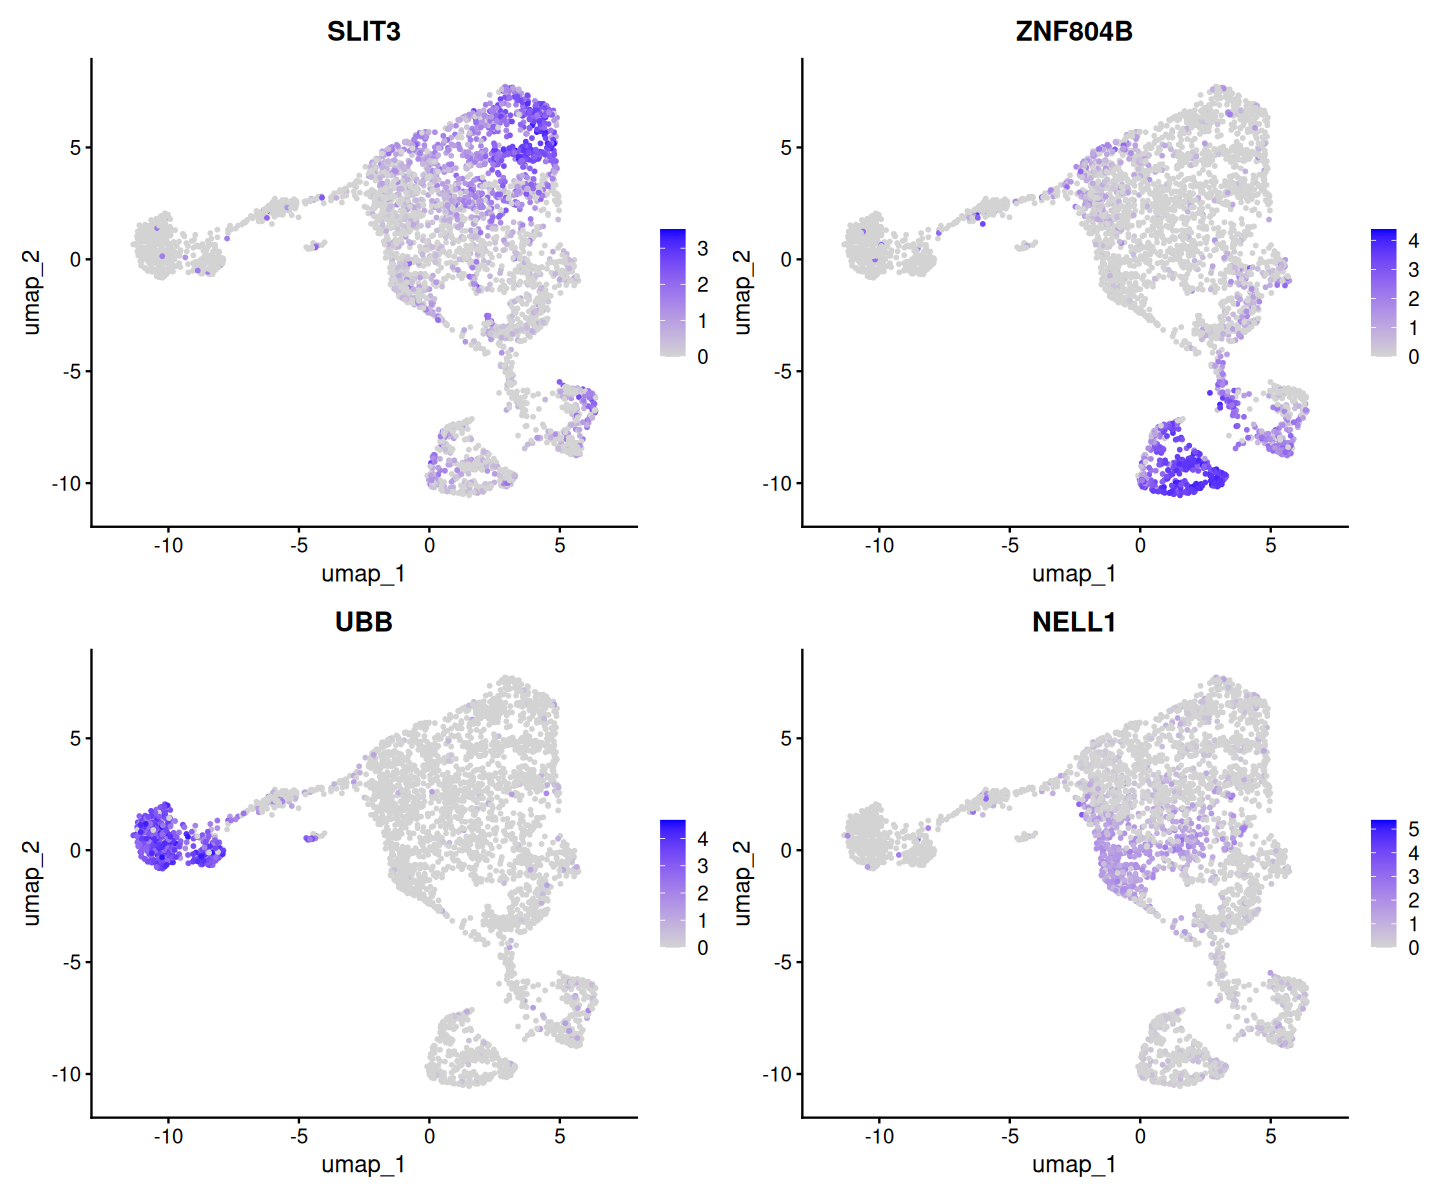

In [122]:
options(repr.plot.width=12, repr.plot.height=10)
FeaturePlot(sub2, features = c("SLIT3","ZNF804B","UBB","NELL1"), ncol = 2, raster = FALSE)
# FeaturePlot(sub2, features = c("CALCR","FAM83B","NXPH1","ACTB"), ncol = 2, raster = FALSE)

In [123]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_top_markers.pdf', width = 12, height = 10)
options(repr.plot.width=12, repr.plot.height=10)
FeaturePlot(sub2, features = c("SLIT3","ZNF804B","UBB","NELL1"), ncol = 2, raster = FALSE)
dev.off()

agg_record_245519403 
                   2

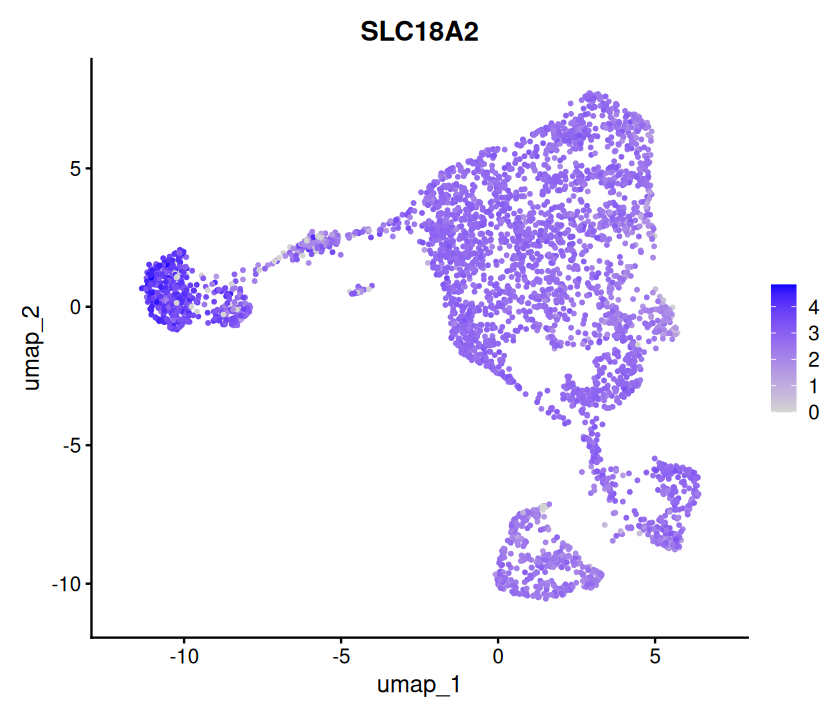

In [121]:
options(repr.plot.width=7, repr.plot.height=6)
FeaturePlot(sub2, features = c("SLC18A2"), ncol = 1, raster = FALSE)

In [107]:
pdf("/mnt/90-connectome/Personal/CQW/midbrain/figure/DA_top_markers_dotplot.pdf",
    width = 6, height = 8)

DotPlot(sub2, features = unique(markers_filt_top10$gene), dot.scale = 6, group.by = "cluster") +
    coord_flip() + RotatedAxis(45) +
    theme(axis.text.y = element_text(size = 12), axis.text.x = element_text(size = 12)) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

dev.off()


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


agg_record_312928385 
                   2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


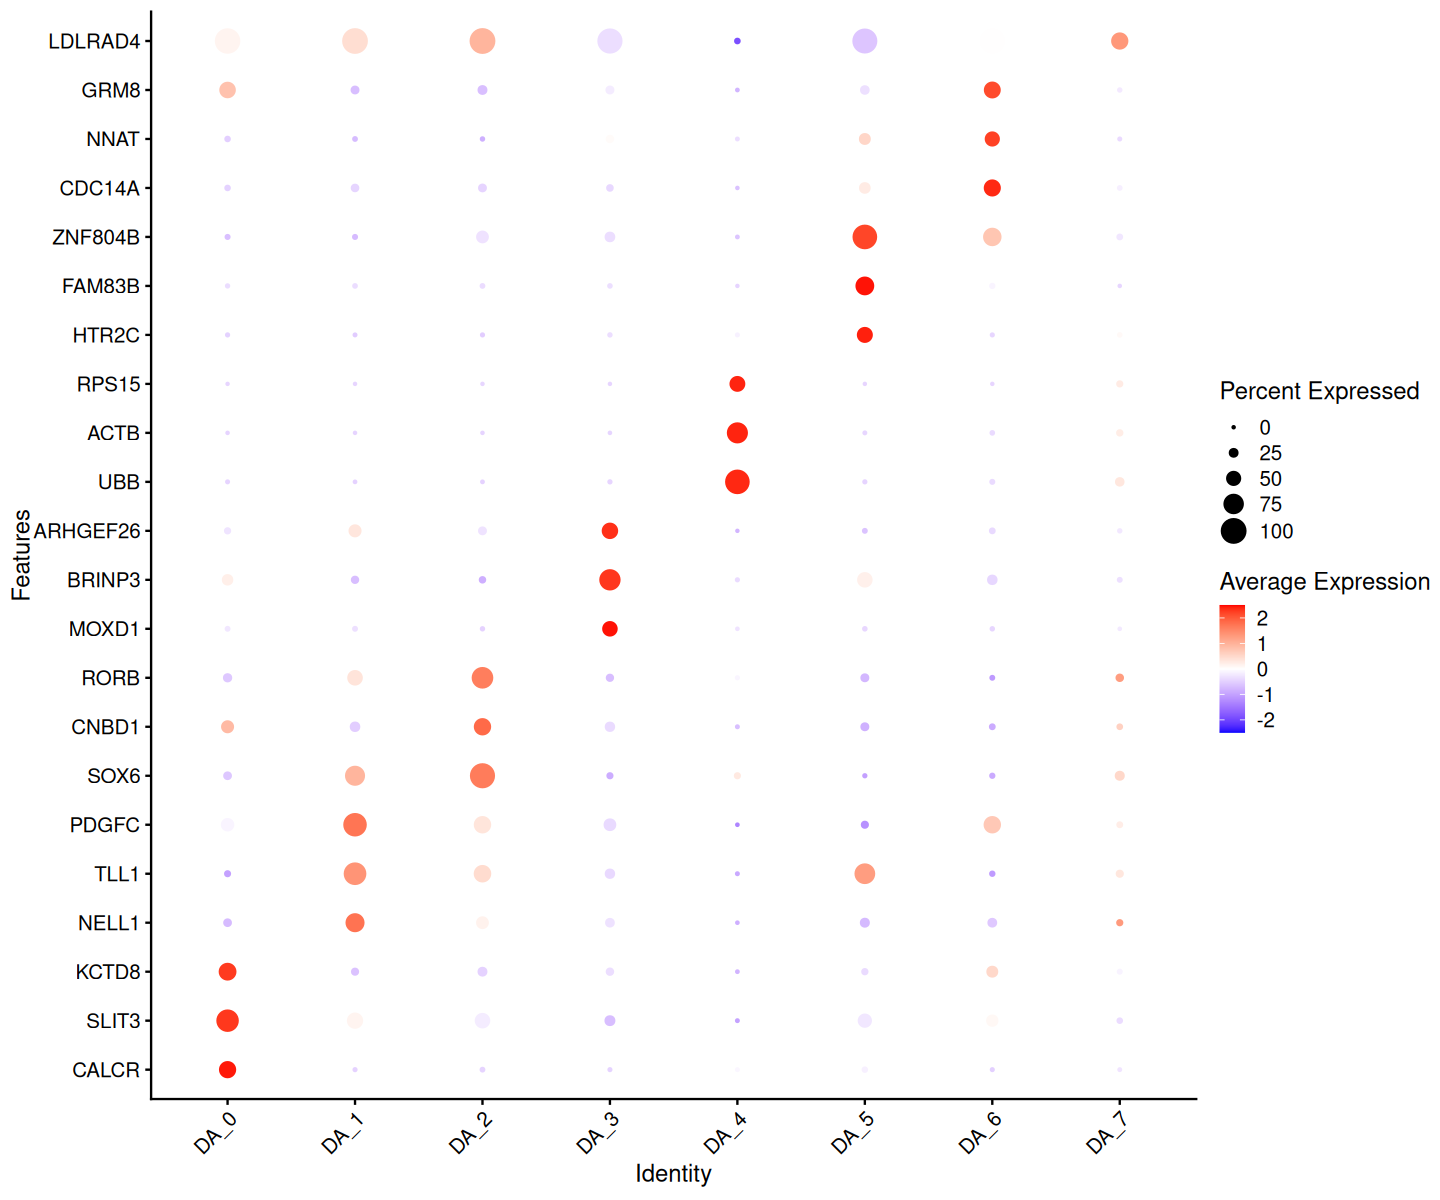

In [109]:
options(repr.plot.width=12, repr.plot.height=10)
DotPlot(sub2, features = unique(markers_filt_top10$gene), dot.scale = 6, group.by = "cluster") +
    coord_flip() + RotatedAxis(45) +
    theme(axis.text.y = element_text(size = 12), axis.text.x = element_text(size = 12)) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

In [39]:
markers_filt_top50 = markers_filt %>% group_by(cluster) #%>% top_n(n = 100, wt = avg_log2FC)

gene_list_olg_up <- split(markers_filt_top50$gene,markers_filt_top50$cluster)
gene_list_olg_up

$`0`
  [1] "RUNX1T1"     "CACNA2D3"    "PBX3"        "PTPRG"       "PLCB4"      
  [6] "SLIT3"       "CALCR"       "SLC35D2"     "ZBTB7C"      "ROBO1"      
 [11] "NPNT"        "IL1RAPL2"    "CDH20"       "ERBB4"       "MAGI2"      
 [16] "SLC8A1"      "TMEFF2"      "KCTD8"       "RERG"        "KIRREL3"    
 [21] "CDH4"        "EBF3"        "ASIC2"       "PDZRN3"      "ARPP21"     
 [26] "CEP112"      "FNDC3B"      "DOK5"        "LSAMP"       "IQCJ-SCHIP1"
 [31] "LAMA3"       "PCSK2"       "TOX"         "PLXNC1"      "SLC17A8"    
 [36] "ABTB2"       "CDH6"        "NKAIN2"      "CALB1"       "ZDHHC2"     
 [41] "BDNF"        "CACHD1"      "IQCJ"        "TMCC3"       "COBL"       
 [46] "KCNH7"       "NRXN3"       "FGF20"       "RBFOX1"      "STXBP5L"    
 [51] "RPH3A"       "ANO4"        "DCC"         "GPR149"      "SGCZ"       
 [56] "PDE8B"       "ST6GALNAC5"  "MARCH1"      "LIMS1"       "EFNA5"      
 [61] "LEMD1"       "CSMD2"       "PTPRS"       "SORCS2"      "TMTC2"      
 [66] "PRKCA"       "TOX2"        "PXDN"        "PLA2R1"      "VWA5B1"     
 [71] "BNC2"        "EEPD1"       "LRRTM4"      "ARHGAP26"    "SHISA9"     
 [76] "PRICKLE1"    "NTNG1"       "SLC44A5"     "LDB2"        "NRG3"       
 [81] "FHIT"        "FBXL17"      "ZSWIM6"      "SNTG1"       "PDZRN4"     
 [86] "GRIN3A"      "UNC13C"      "GRM8"        "SNTB1"       "CACNG2"     
 [91] "CPNE8"       "CADM1"       "ITGA9"       "N4BP2L1"     "CPNE4"      
 [96] "PLEKHA7"     "COL4A5"      "ZSWIM5"      "GALNTL6"     "KCNIP4"     
[101] "THTPA"       "FOXP2"       "CDK14"       "MAST2"       "GALNT18"    
[106] "EMB"         "LMO4"        "IGF1"        "PTCHD1"      "KIAA1958"   
[111] "PARVA"       "PCDH15"      "ZMAT4"       "TERT"        "HECTD2"     
[116] "THSD4"       "CACNA1C"     "GRIK4"       "SNTG2"       "ADCY2"      
[121] "DOCK7"       "SCN1A"       "DENND2A"     "GREB1L"      "SMOC1"      
[126] "BCL2"        "MED12L"      "PDE1C"       "ZNF423"      "USP13"      
[131] "PCBP4"       "MAML3"       "SLC24A4"     "TRPC6"       "SGCD"       
[136] "TEAD1"       "L3MBTL4"     "ITPR2"       "CCKAR"       "CHRNA5"     
[141] "ARHGAP28"    "HABP4"       "MYO1D"       "FANCC"       "RAB27B"     
[146] "ZNF618"      "MPP7"        "ANTXR1"      "ADAM28"      "ZFHX2"      
[151] "ALK"         "MOCOS"       "MTA3"        "RASGEF1B"    "STC1"       
[156] "AMOTL1"      "VAT1L"       "TENM2"       "TTC39B"      "HIP1"       
[161] "CLVS2"       "RPS6KA2"     "ZNF385B"     "CTDSPL"      "IKBKB"      
[166] "TBC1D1"      "CDC14B"      "NPFFR2"      "SETD7"       "TENM3"      
[171] "GNA14"       "TMEM56"      "NHS"         "BEND7"       "SSBP2"      
[176] "LMX1A"       "LRTM1"       "THBS3"       "EBF2"        "BAZ2B"      
[181] "PKD2"        "STK32B"      "KITLG"       "PDE9A"       "MXD4"       
[186] "MYOM1"       "CLTCL1"      "PIK3R3"      "TRPC3"       "SULF2"      
[191] "SLC1A1"      "UTRN"        "TRANK1"      "ADGRL2"      "IGFBP7"     
[196] "SLC43A2"     "LGR6"        "SPOCK1"      "SHC3"        "SPATA6L"    
[201] "SFMBT1"      "RAVER2"      "SHH"         "TLE3"        "SCUBE1"     
[206] "ECHDC2"      "DOCK5"       "TPK1"        "SLIT2"       "KLHL5"      
[211] "PKNOX2"      "GRIP2"       "DNAJC1"      "MYO16"       "IQCB1"      
[216] "FOXO3"       "LPP"         "SPEF2"       "C11H12orf56" "KLHL8"      
[221] "C1orf21"     "CCDC192"     "CEMIP"       "PTK7"        "RGS20"      
[226] "RXRA"        "MEIOB"       "AFF1"        "PRSS55"      "SLC6A7"     
[231] "USP6NL"      "NEK5"        "OPRK1"       "RASA3"       "TACR3"      
[236] "CERCAM"      "SLC5A8"      "ZC3H12C"     "N4BP2"       "HFM1"       
[241] "PRTFDC1"     "CYP39A1"     "CNBD1"       "SYNE2"       "KCNQ5"      
[246] "WNT5A"       "METTL4"      "LIMA1"       "TOX3"        "ZNF608"     
[251] "CPNE5"       "ZBTB46"      "LEF1"        "ADRA1B"      "ZNF367"     
[256] "PRTG"        "NABP1"       "GABRG3"      "CHRNA3"      "STXBP3"     
[261] "CROCC"       "ADAMTS19"    "KCTD9"  

In [40]:
library(enrichR)
gene_list_olg_up = gene_list_olg_up[sapply(gene_list_olg_up, length) > 0]
lapply(names(gene_list_olg_up), function(x){
  enrichr(gene_list_olg_up[[x]], c("GO_Biological_Process_2025"))$GO_Biological_Process_2025 %>%
    mutate(seurat_clusters = x)
}) %>% bind_rows() -> GO_df_up1

Welcome to enrichR
Checking connections ... 

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!



Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.


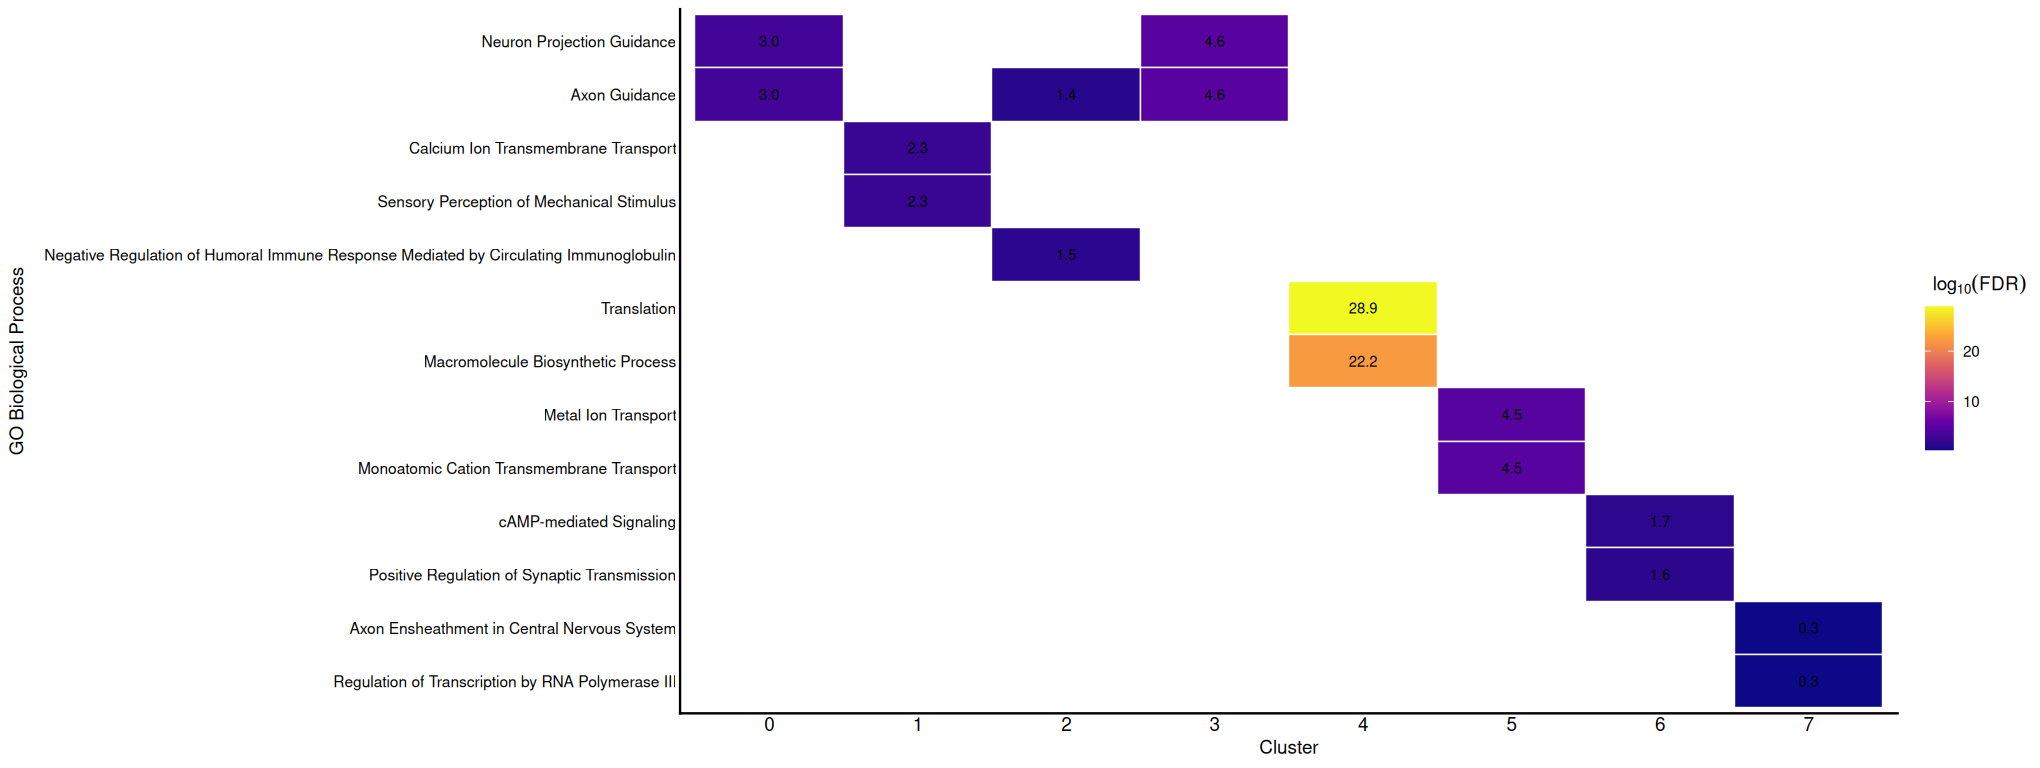

In [41]:
# 每个 cluster 取 FDR 最小的前 2 个 GO term，并绘制富集热图
GO_top2 = GO_df_up1 %>%
    filter(!is.na(Adjusted.P.value), Adjusted.P.value > 0) %>%
    group_by(seurat_clusters) %>%
    slice_min(order_by = Adjusted.P.value, n = 2, with_ties = FALSE) %>%
    ungroup() %>%
    mutate(
        enrichment_score = -log10(Adjusted.P.value),
        Term = sub(" \\(GO:.*\\)$", "", Term),
        Term = factor(Term, levels = rev(unique(Term)))
    )

GO_heatmap = ggplot(GO_top2, aes(x = factor(seurat_clusters), y = Term, fill = enrichment_score)) +
    geom_tile(color = "white", linewidth = 0.3) +
    geom_text(aes(label = sprintf("%.1f", enrichment_score)), size = 3) +
    scale_fill_viridis_c(name = expression(-log[10](FDR)), option = "C") +
    labs(x = "Cluster", y = "GO Biological Process") +
    theme_classic() +
    theme(
        axis.text.x = element_text(size = 11),
        axis.text.y = element_text(size = 9),
        axis.ticks = element_blank()
    )

options(repr.plot.width = 17, repr.plot.height = max(5, 0.4 * nrow(GO_top2)))
print(GO_heatmap)